# NicheSphere × PILOT: niche-based trajectory inference

This tutorial demonstrates how to combine **NicheSphere** niches with **[PILOT](https://github.com/CostaLab/PILOT)** to compute sample-level disease trajectories from spatial transcriptomics data.

[PILOT](https://github.com/CostaLab/PILOT) (Polyphony Informed Latent Optimal Transport) computes distances between tissue samples using optimal transport on cell type proportions. By using NicheSphere niches as the grouping variable — rather than individual cell types — we obtain niche-informed distances that better reflect the spatial organisation of disease.

**Prerequisites:** This tutorial assumes you have cloned the NicheSphere github repo and run the main NicheSphere MI Visium tutorial (`Nichesphere_tutorial_MIvisium.ipynb`) and have the following files available under `NicheSphere/data/`:
- `heart_MI_ST_SC_23samples.h5mu` — MuData object with Visium and scRNA-seq data
- `CTprops.csv` — cell type proportions per spot
- `colocPerSample.csv` — co-localization probabilities per sample
- `niches_df_MIvisium_louvain.csv` — niche–cell type–color correspondence table
- `MI_sampleTypesDF.csv` — sample–condition mapping

**In this tutorial** we will:
1. Prepare spot-level niche annotations from co-localization niches
2. Compute sample-to-sample Wasserstein distances using PILOT
3. Infer a disease trajectory and compute pseudotime
4. Identify niches and cell type pair co-localizations that change along the trajectory


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import scanpy as sc
import mudata as md
import pilotpy as pl


## 2. Data

We load the MI Visium MuData object and the outputs from the NicheSphere co-localization tutorial.


In [2]:
mudata = md.read('../../data/MIvisium/PILOT_tutorial/heart_MI_ST_SC_23samples.h5mu')

sampleTypesDF = pd.read_csv('../../data/MIvisium/PILOT_tutorial/MI_sampleTypesDF.csv', index_col=0)
CTprops       = pd.read_csv('../../data/MIvisium/PILOT_tutorial/CTprops.csv', index_col=0)
coloc         = pd.read_csv('../../data/MIvisium/PILOT_tutorial/colocPerSample.csv', index_col=0)

niches_df = pd.read_csv('../../data/MIvisium/PILOT_tutorial/niches_df_MIvisium_louvain.csv')
niches_df['niche'] = niches_df['niche'].astype('category')


### Co-localization table

Since co-localization between cell type A–B equals that of B–A, we remove duplicate columns to avoid counting them twice. We then multiply the remaining non-self-interaction pairs by 2 to preserve the correct scale.


In [3]:
cell_types = CTprops.columns
oneCTints  = cell_types + '-' + cell_types  # same-cell-type pairs

coloc = coloc.T.drop_duplicates().T
coloc[np.setdiff1d(coloc.columns, oneCTints)] *= 2
coloc.head()


,Fib1_SCARA5-Fib1_SCARA5,Fib1_SCARA5-damaged_CM,Fib1_SCARA5-Capillary_Endo,Fib1_SCARA5-LYVE_FOLR_Macrophages,Fib1_SCARA5-Fib3_C7,Fib1_SCARA5-healthy_CM,Fib1_SCARA5-Fib2_Myofib,Fib1_SCARA5-Endocardial_Endo,Fib1_SCARA5-Arterial_Endo,Fib1_SCARA5-Neuronal,...,NK-CD_8,NK-Adipo,NK-NK_T,CD_8-CD_8,CD_8-Adipo,CD_8-NK_T,Purkinje_fibers-Purkinje_fibers,Adipo-Adipo,Adipo-NK_T,NK_T-NK_T
control_P17,0.017603,0.000617,0.001985,0.000501,0.014124,0.005172,0.009448,0.001886,0.000824,0.000702,...,0.000143,0.0,9.077312e-08,0.001856,0.0,9.112006e-08,0.000143,0.000000,0.000000e+00,0.000268
RZ_P9,0.009307,0.000858,0.001475,0.000007,0.010408,0.002878,0.003250,0.000129,0.000336,0.000091,...,0.000420,0.0,1.990927e-04,0.001618,0.0,3.286973e-05,0.000249,0.000571,0.000000e+00,0.000784
IZ_P15,0.030351,0.000000,0.000054,0.000372,0.002401,0.000000,0.006223,0.000145,0.000123,0.000000,...,0.000000,0.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
RZ_P6,0.040470,0.000882,0.005503,0.000722,0.017374,0.005856,0.015756,0.000352,0.002045,0.002340,...,0.000141,0.0,1.718785e-27,0.001029,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000438
RZ_BZ_P3,0.021508,0.000585,0.001135,0.000115,0.004816,0.000966,0.013271,0.000245,0.000105,0.000103,...,0.000375,0.0,1.717062e-05,0.001783,0.0,0.000000e+00,0.000373,0.001115,1.458913e-34,0.000897


## 3. Prepare data for PILOT

PILOT requires a spot-level AnnData with:
- `obs['niche']` — the dominant niche for each spot (based on cell type proportions)
- `obs['patient_region_id']` — sample identifier
- `obs['status']` — condition label
- `obsm['CTprops']` — cell type proportions per spot (used to compute niche-to-niche cost matrices)

We assign each spot to its dominant niche by finding the niche with the highest summed cell type proportion.


In [4]:
all_niches = pd.DataFrame()

for smpl in sampleTypesDF['sample'].unique():
    tmp = mudata['visium'][mudata['visium'].obs.patient_region_id == smpl].copy()
    tmp.obs['status'] = sampleTypesDF.loc[sampleTypesDF['sample'] == smpl, 'sampleType'].values[0]

    # Compute niche proportion per spot as sum of constituent cell type proportions
    for niche in niches_df.niche.cat.categories:
        tmp.obs[niche] = CTprops[list(niches_df.cell[niches_df.niche == niche])].sum(axis=1)

    niche_props = tmp.obs[list(niches_df.niche.cat.categories)]
    tmp.obs['niche'] = [niche_props.columns[np.argmax(niche_props.loc[idx])] for idx in niche_props.index]
    tmp.obs['niche'] = tmp.obs['niche'].astype('category')

    # Ensure all niche categories are present (required for PILOT)
    for c in np.setdiff1d(list(niches_df.niche.cat.categories), tmp.obs.niche.cat.categories):
        tmp.obs['niche'] = tmp.obs['niche'].cat.add_categories(c)
    tmp.obs['niche'] = tmp.obs['niche'].cat.reorder_categories(list(niches_df.niche.cat.categories))

    all_niches = pd.concat([all_niches, tmp.obs[['niche', 'patient_region_id', 'status']]])


Remote zone samples are healthy tissue from a diseased patient — we simplify them to `'myogenic'` to group them with controls:

In [5]:
all_niches['status'] = ['myogenic' if x == 'remote' else x for x in all_niches['status']]
all_niches['status'].value_counts()


status
myogenic    27357
fibrotic    18571
ischemic    16552
border      11424
Name: count, dtype: int64

In [6]:
adata = mudata['visium'].copy()
adata.obs = all_niches

adata.obsm['CTprops'] = CTprops.loc[all_niches.index].fillna(0)
adata


AnnData object with n_obs × n_vars = 73904 × 11704
    obs: 'niche', 'patient_region_id', 'status'
    var: 'features'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'CTprops'

## 4. PILOT trajectory inference

### Wasserstein distances between samples

`pl.tl.wasserstein_distance` computes optimal transport distances between samples using:
- `emb_matrix='CTprops'` — cell type proportions as the embedding for computing niche-to-niche costs
- `clusters_col='niche'` — niches as the grouping variable
- `sample_col='patient_region_id'` — sample identifier column
- `status='status'` — condition column


In [7]:
pl.tl.wasserstein_distance(
    adata,
    emb_matrix='CTprops',
    clusters_col='niche',
    sample_col='patient_region_id',
    status='status',
    use_centroids=False
)


### Disease trajectory

A diffusion map on the Wasserstein distances reveals the trajectory of disease progression. Samples are colored by condition.


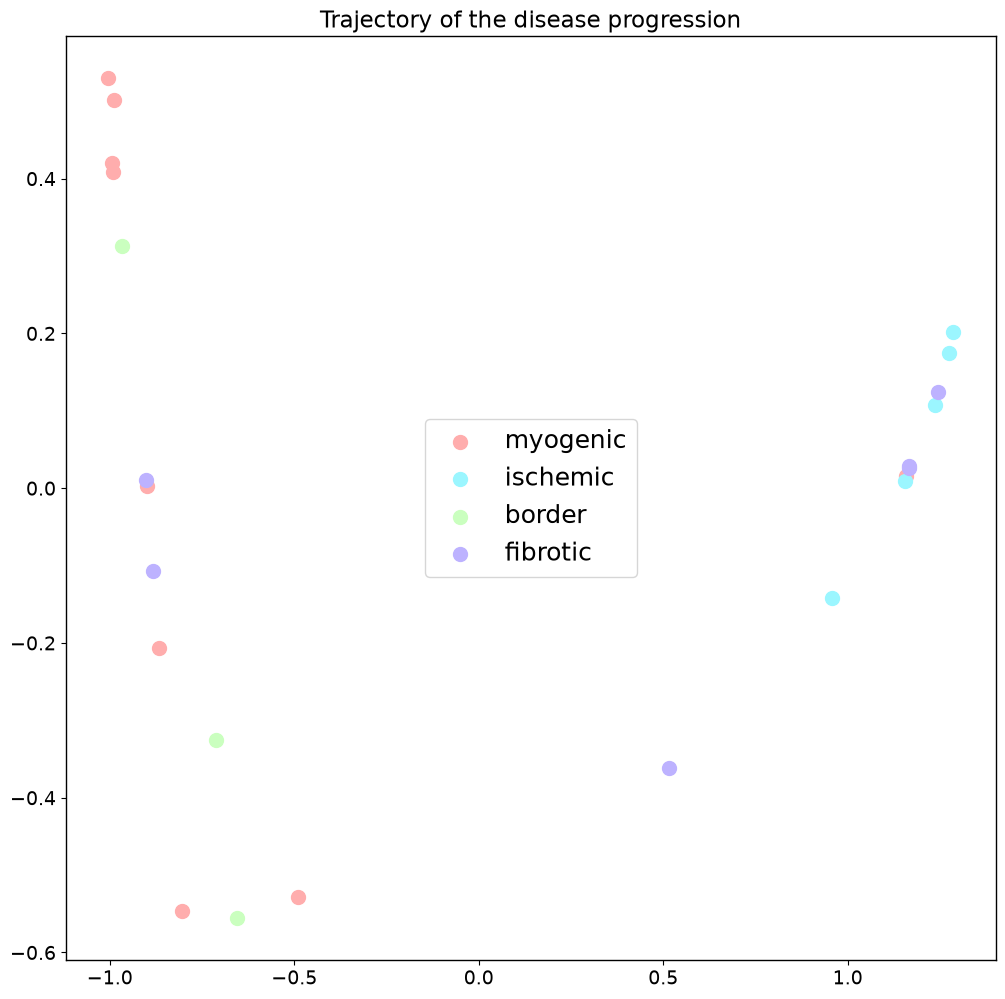

In [8]:
clist = ['#ffadad', '#9bf6ff', '#caffbf', '#bdb2ff']

pl.pl.trajectory(
    adata,
    colors=clist,
    font_size=14,
    location_labels='center',
    fontsize_legend=18,
    knn=8  # number of nearest neighbors for the diffusion map kernel
)


### Principal graph and pseudotime

PILOT fits a principal graph to the diffusion map embedding to extract the trajectory structure, then assigns a pseudotime score to each sample. `source_node` should correspond to the healthy/control end of the trajectory.


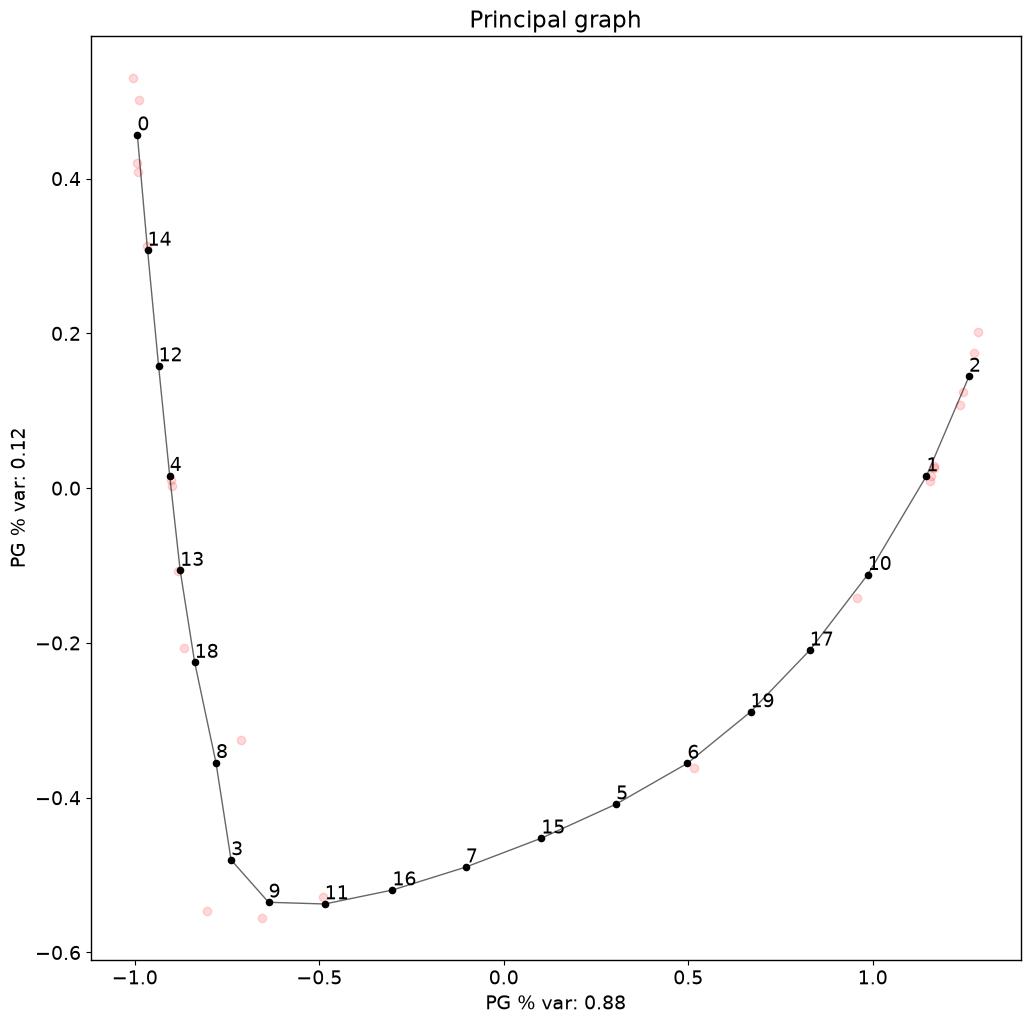

RZ_P9          0.000000
control_P7     0.000000
control_P17    0.035963
RZ_P11         0.047699
RZ_BZ_P2       0.146113
FZ_P14         0.455092
RZ_GT_P2       0.463537
RZ_FZ_P5       0.573682
RZ_P6          0.672856
RZ_BZ_P3       0.841562
control_P1     0.973713
RZ_BZ_P12      1.083839
control_P8     1.236007
FZ_GT_P4       2.257199
GT_IZ_P9       2.748780
IZ_P10         2.994684
RZ_P3          3.002130
FZ_P20         3.015600
FZ_GT_P19      3.017235
GT_IZ_P15      3.123411
FZ_P18         3.142166
IZ_P15         3.167037
GT_IZ_P13      3.167037
dtype: float64

In [9]:
pl.pl.fit_pricipla_graph(adata, source_node=0)

# Samples sorted by pseudotime
PT = pd.Series(
    adata.uns['pseudotime'],
    index=list(adata.uns['proportions'].keys())
).sort_values()
PT


## 5. Interpretability

### 5.1 Niche proportions along the trajectory

`pl.tl.cell_importance` fits a robust regression model to identify niches whose proportions change linearly or non-linearly along the pseudotime trajectory.


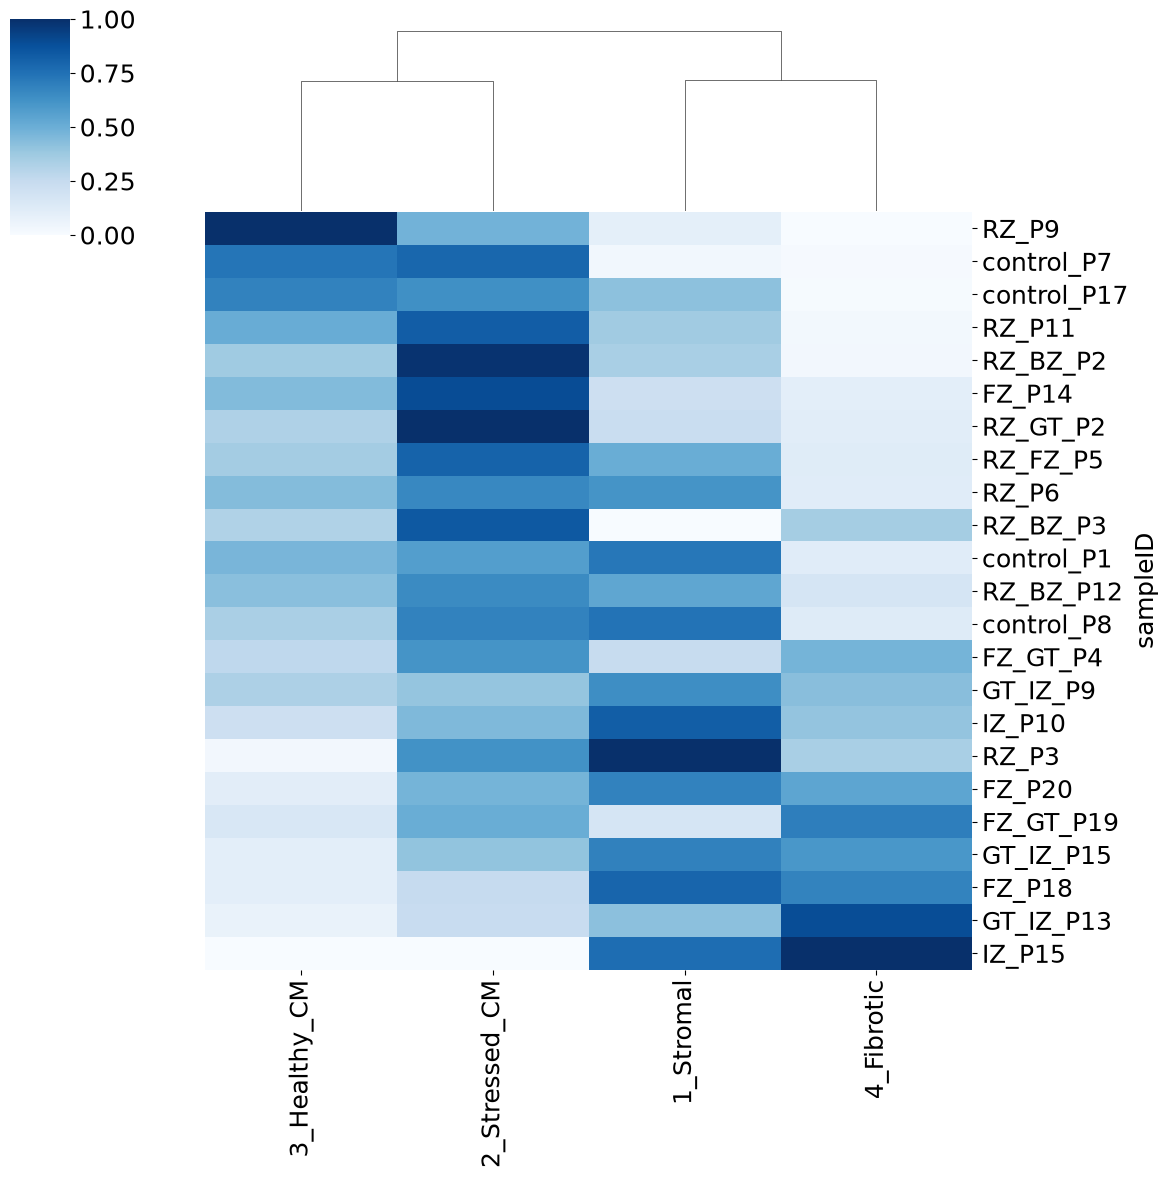

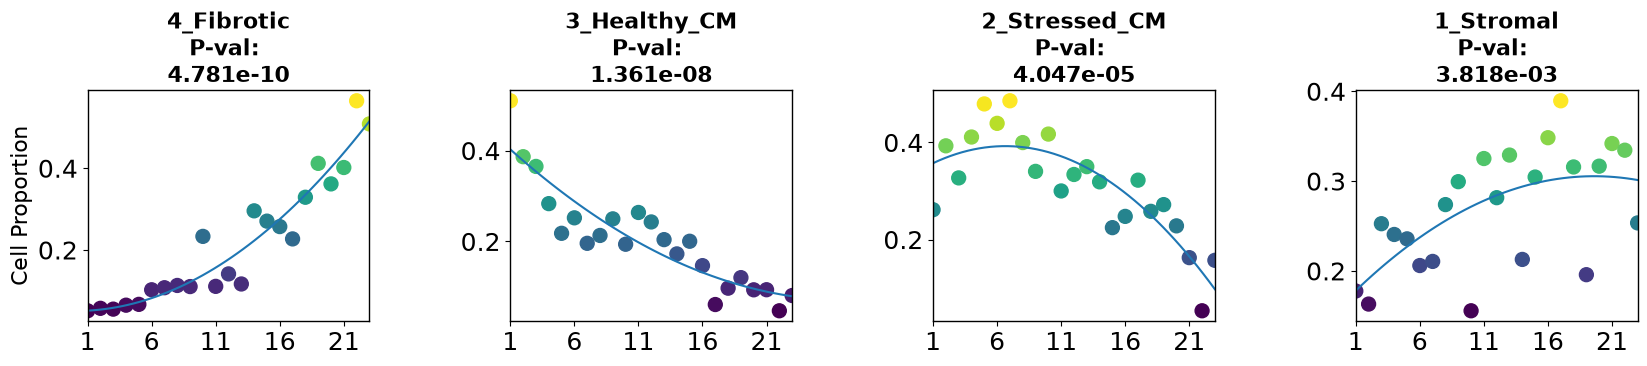

In [10]:
plt.rcParams.update({'font.size': 18})

pl.tl.cell_importance(
    adata,
    height=3,
    width=20,
    fontsize=16
)


### 5.2 Visium slices along the trajectory

We visualize how niche proportions shift across slices by plotting each slice colored by dominant niche, then arranging them in a grid sorted by pseudotime.


In [11]:
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('results/PILOT', exist_ok=True)

col_list = ['#4daf4a', '#0072B5', '#BC3C29', '#ffff33']
adata.uns['niche_colors'] = col_list

# Plot and save each slice
for smpl in sampleTypesDF['sample']:
    sc.pl.spatial(
        adata=adata[adata.obs.patient_region_id == smpl].copy(),
        color='niche',
        img_key=None,
        library_id=None,
        spot_size=0.015,
        title='',
        frameon=False,
        legend_loc=None,
        save=f'_{smpl}_niches.png',
        legend_fontsize=6,
        size=1.5,
        show=False
    )


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

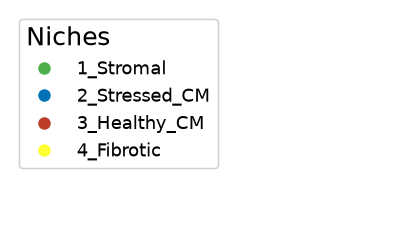

In [12]:
# Niche color legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col_list[i],
               lw=4, label=list(adata.obs.niche.cat.categories)[i], ms=10)
    for i in range(len(adata.obs.niche.cat.categories))
]
fig, ax = plt.subplots(figsize=(5, 3))
ax.add_artist(plt.legend(handles=legend_elements, loc='upper left', fontsize=13,
                          title='Niches', alignment='left'))
ax.axis('off')


In [13]:
# Workaround for missing imports in pilotpy — inject them into PILOT's plotting module
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pilotpy.plot.ploting as _pilot_plot
_pilot_plot.OffsetImage = OffsetImage
_pilot_plot.AnnotationBbox = AnnotationBbox

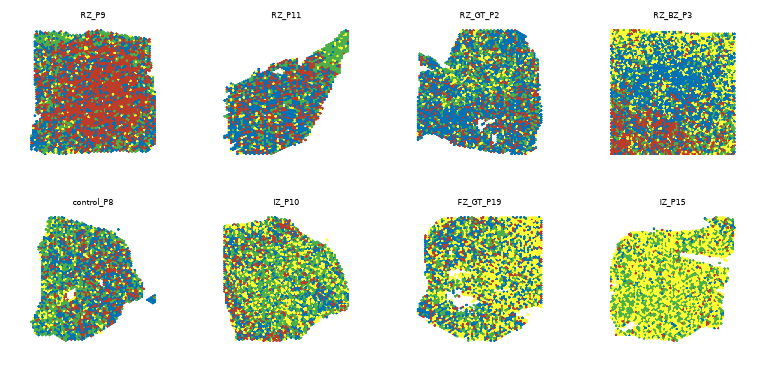

Saved grid to results/PILOT/slices_niches_by_pseudotime.pdf


In [14]:
# Arrange slices in a grid sorted by pseudotime
pl.pl.create_sample_grid(
    df=adata.uns['orders'][::3],
    pattern='niches',
    image_dir='figures/',
    output_path='results/PILOT/slices_niches_by_pseudotime.pdf',
    zoom=0.27,
    num_rows=2
)


### 5.3 Cell type pair co-localization along the trajectory

We can also ask which **cell type pair co-localization probabilities** are most relevant for disease progression, by correlating them with pseudotime using Spearman's rank correlation.


In [15]:
# Spearman correlation of each cell type pair co-localization with pseudotime
stats = [scipy.stats.spearmanr(coloc[c][PT.index], PT) for c in coloc.columns]

df = pd.DataFrame({
    'pairs':     coloc.columns,
    'statistic': [s.statistic for s in stats],
    'p-value':   [s.pvalue    for s in stats]
}).set_index('pairs').sort_values('p-value')

df.head(10)


,statistic,p-value
pairs,,
healthy_CM-intermediate_CM,-0.904629,3.140281e-09
healthy_CM-healthy_CM,-0.873829,5.155859e-08
healthy_CM-Pericyte_2,-0.870959,6.443950e-08
Pericyte_1-intermediate_CM,-0.861410,1.305091e-07
Capillary_Endo-intermediate_CM,-0.860416,1.400318e-07
Fib2_Myofib-Lymphatic_Endo,0.853188,2.301131e-07
intermediate_CM-Pericyte_2,-0.843694,4.251980e-07
healthy_CM-Arterial_Endo,-0.840048,5.325711e-07
intermediate_CM-vCM_3,-0.837564,6.189076e-07


We select the top co-localization pairs positively and negatively correlated with pseudotime (p < 0.05, |ρ| > 0.6), excluding same-cell-type pairs:

In [16]:
sig = df[df['p-value'] < 0.05]

pairs_pos = list(np.setdiff1d(sig[sig['statistic'] >  0.6].index, oneCTints))[:4]
pairs_neg = list(np.setdiff1d(sig[sig['statistic'] < -0.6].index, oneCTints))[:4]

print("Positively correlated:", pairs_pos)
print("Negatively correlated:", pairs_neg)


Positively correlated: ['Fib2_Myofib-CCL18_Macrophages', 'Fib2_Myofib-LYVE_PLTP_Macrophages', 'Fib2_Myofib-Lymphatic_Endo', 'Fib2_Myofib-Monocytes']
Negatively correlated: ['Arterial_Endo-Fib4_COL15A1', 'Arterial_Endo-Pericyte_1', 'Arterial_Endo-Pericyte_2', 'Arterial_Endo-intermediate_CM']


In [17]:
coloc_sub = coloc[pairs_pos + pairs_neg]

# Store in AnnData for PILOT's feature_importance function
adata.uns['coloc_names']       = list(coloc_sub.columns)
adata.uns['proportions_coloc'] = dict(zip(coloc_sub.index, coloc_sub.values))


`pl.tl.feature_importance` applies the same robust regression model as `cell_importance`, but on arbitrary sample-level features stored in `adata.uns`:

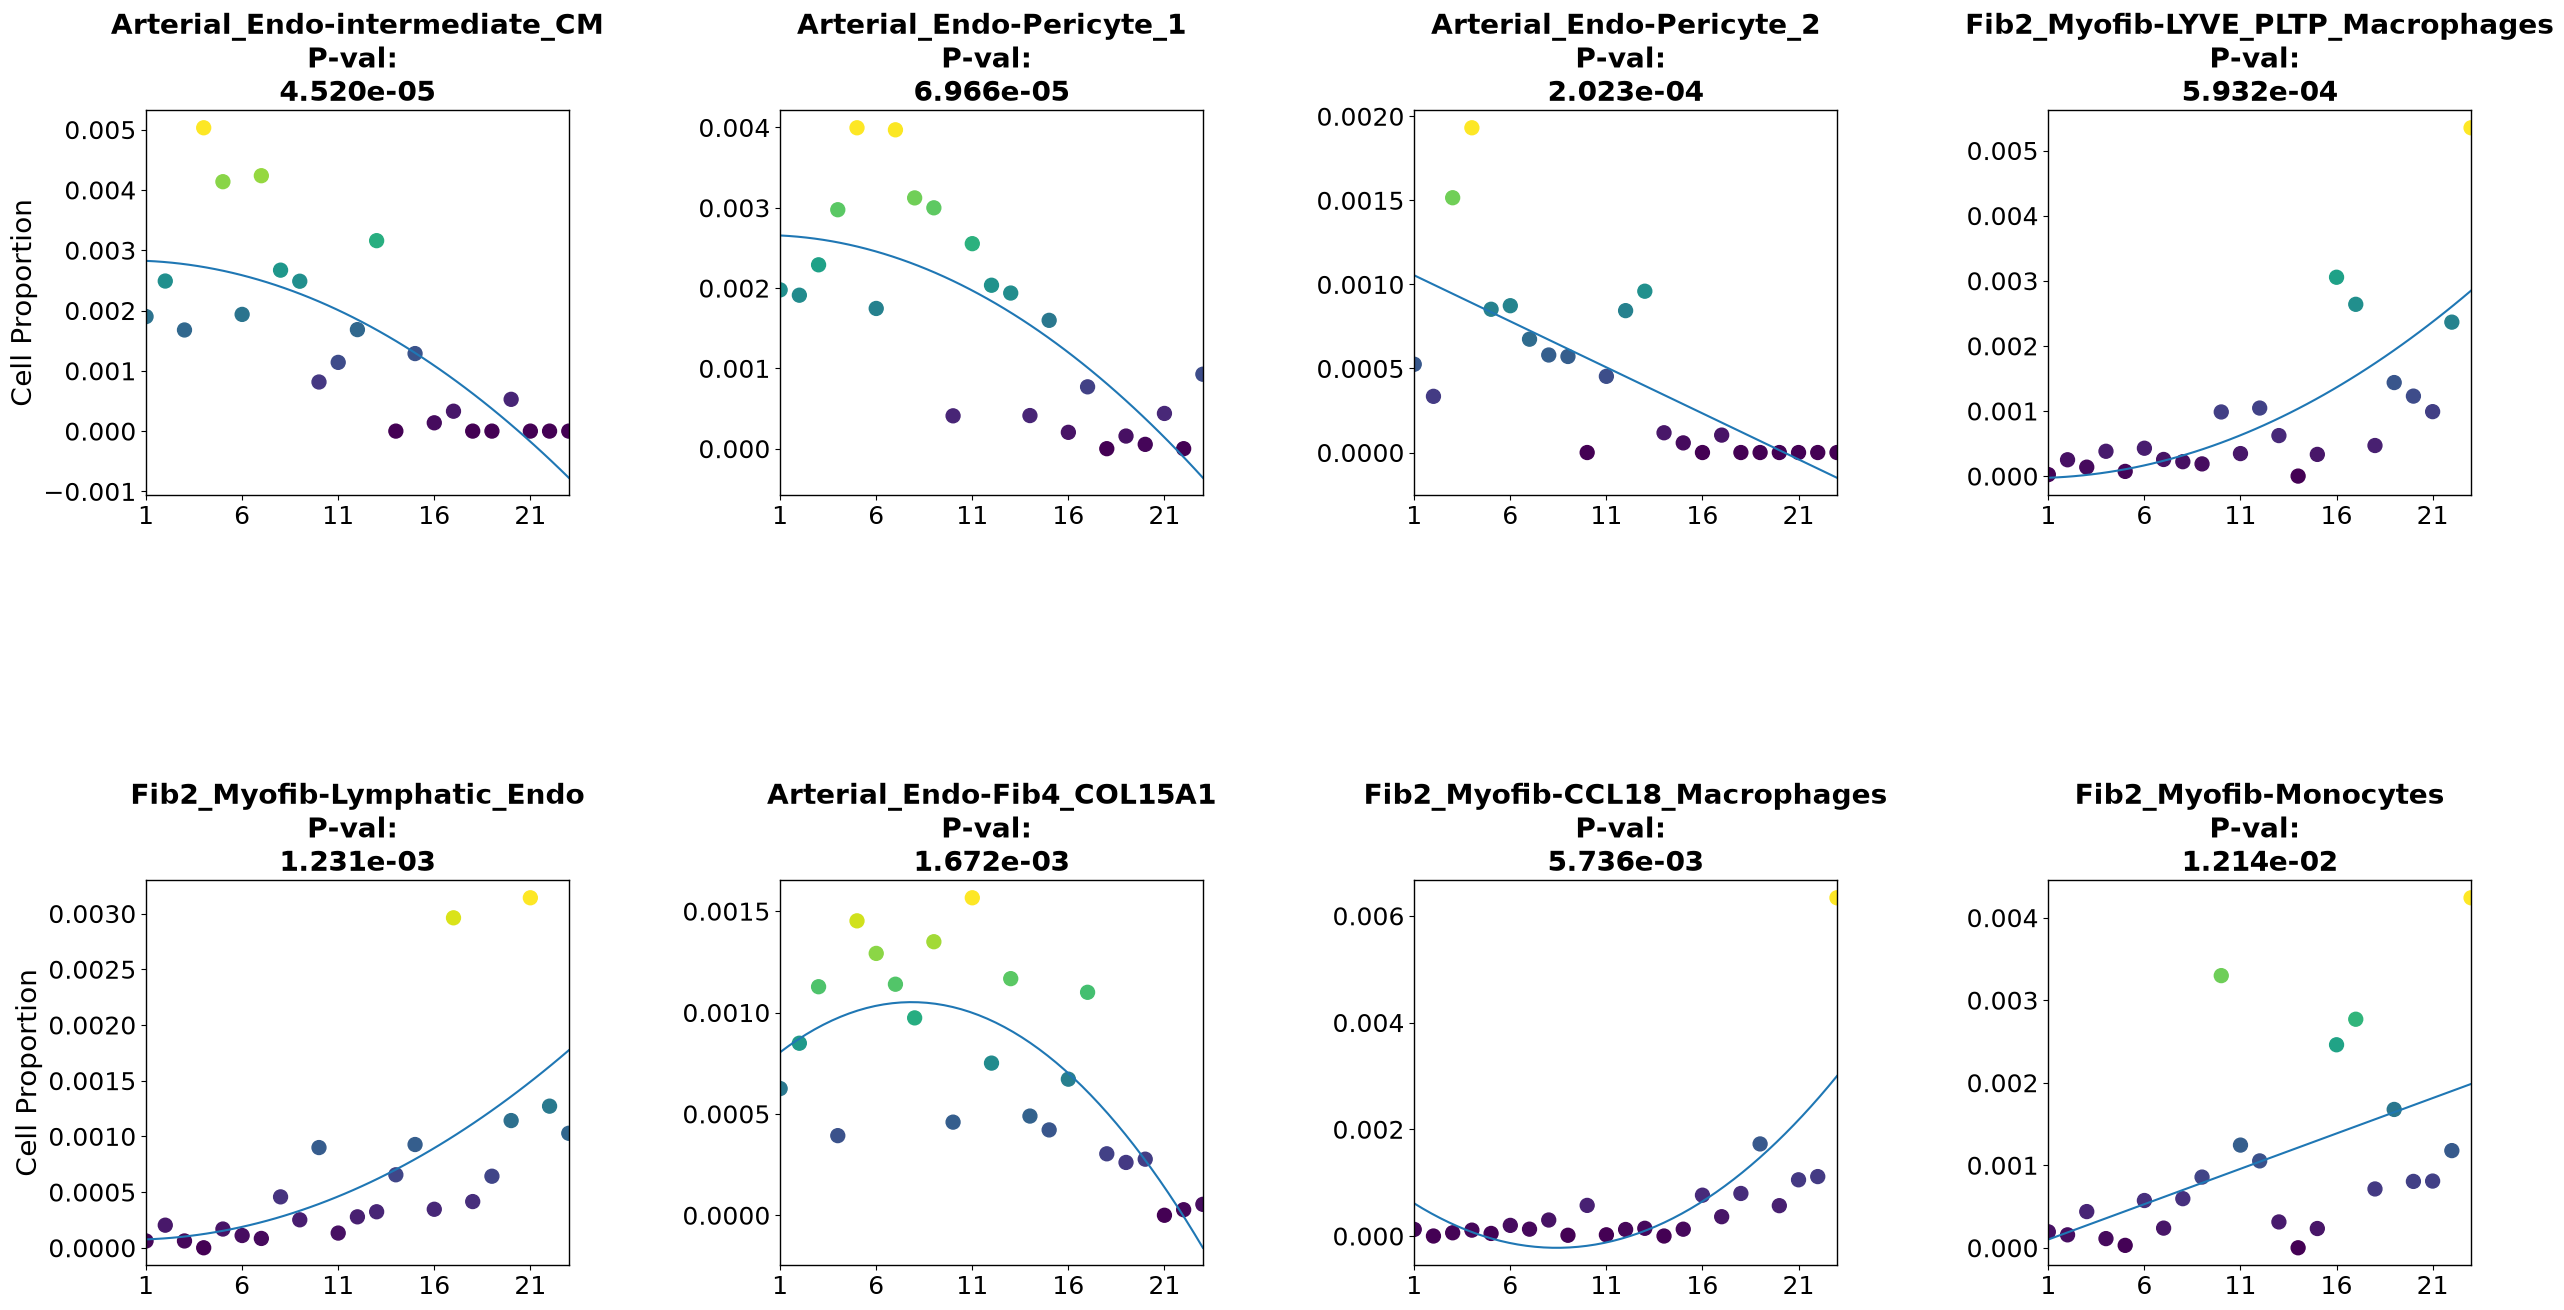

In [18]:
pl.tl.feature_importance(
    adata,
    feature_matrix='proportions_coloc',
    feature_names='coloc_names',
    height=15,
    width=30,
    fontsize=20,
    figsize=(6, 6)
)
plt.savefig('figures/coloc_pairs_trajectory.pdf', bbox_inches='tight')


---

This concludes the NicheSphere × PILOT tutorial. We have shown how to:

- Assign Visium spots to NicheSphere niches and use them as PILOT grouping variables
- Compute niche-informed Wasserstein distances between tissue samples
- Infer a disease progression trajectory and pseudotime ordering
- Identify niches and cell type pair co-localizations that drive disease progression

For the full co-localization and communication analysis, see `Nichesphere_tutorial_MIvisium.ipynb`.
